# Computer Vision Project

##Imports


In [ ]:
import os
from google.colab import drive

import copy
import math
import time
import urllib.request
import subprocess
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from tqdm.auto import tqdm
from tqdm import tqdm

import gc

## Globals

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/CV_project'

# Paths to save model weights
STANDARD_ATTENTION_PATH = os.path.join(PROJECT_DIR + '/1_StandardAttention', 'best_weights.pth')
MOH_ATTENTION_PATH = os.path.join(PROJECT_DIR + '/2_MoHAttention', 'best_weights.pth')

# Dataset paths
DATA_DIR = "/content/nights"
CSV_URL = "https://data.csail.mit.edu/nights/nights_unfiltered/nights_raw.csv"
BASE_CHUNK_URL = "https://data.csail.mit.edu/nights/nights_chunked"

# ImageNet weigths for normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Hyperparameters dataset
N_CHUNKS = 50
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 6
LEARNING_RATE = 2e-5

# Backbone pretrained
BASELINE_MODEL_NAME = 'vit_base_patch16_224.dino'

N_UNFROZEN_BLOCKS = 2
N_ADAPT_BLOCKS = 2

# Config MoH
MOH_SHARED_HEADS = 2
MOH_ROUTED_HEADS = 2

# Hyperparametri di training
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.1   # total_step's fraction
GRAD_CLIP_NORM = 1.0
AUX_LOSS_WEIGHT = 0.01

# Dictionaries to store performances of the models {train_acc, val_acc, test_acc}
baseline_performance = {}
standard_performance = {}
moh_performance = {}


# Column names
REF_COL, LEFT_COL, RIGHT_COL = "ref_path", "left_path", "right_path"
PREFIX = "util/2afc_src_images/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Utils

In [ ]:
def get_chunk_id(path):
    return path.split("/")[1]

def show_triplet(ref, left, right, label, tid):
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))

    images = [ref.cpu(), left.cpu(), right.cpu()]
    titles = ["reference", "left", "right"]

    for a, img, title in zip(ax, images, titles):
        a.imshow(img.permute(1, 2, 0))
        a.set_title(title)
        a.axis("off")

    plt.suptitle(f"id={tid}, human vote fraction (left) = {label.item():.2f}")
    plt.show()

def replace_attention(block, new_attn_module):
    block.attn = new_attn_module
    return block

def test_model_performance(model, test_loader, criterion, model_name, device='cuda'):
    model.eval()
    model.to(device)

    test_loss, correct_test, total_test = 0.0, 0, 0
    inference_times = []

    print("Warming-up GPU")
    dummy_ref = torch.randn(1, 3, 224, 224).to(device)
    dummy_left = torch.randn(1, 3, 224, 224).to(device)
    dummy_right = torch.randn(1, 3, 224, 224).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            for _ in range(5):
                emb_ref, emb_left, emb_right = model(dummy_ref, dummy_left, dummy_right)
                sim_l = F.cosine_similarity(emb_ref, emb_left, dim=1)
                sim_r = F.cosine_similarity(emb_ref, emb_right, dim=1)
                _ = sim_l - sim_r

    if device == 'cuda':
        torch.cuda.synchronize()

    print("Beginning test on the test set")
    test_loop = tqdm(test_loader, desc="Testing", leave=False)

    with torch.no_grad():
        for ref, left, right, label, _ in test_loop:
            # Moving tensors to GPU
            ref = ref.to(device, non_blocking=True)
            left = left.to(device, non_blocking=True)
            right = right.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)

            # Start time measuring
            if device == 'cuda':
                torch.cuda.synchronize()
            start_time = time.perf_counter()

            # Forward Pass and Cosine similarity
            with torch.amp.autocast('cuda'):
                emb_ref, emb_left, emb_right = model(ref, left, right)

                sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
                sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)

                logits = sim_left - sim_right

            if device == 'cuda':
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            # End measuring time

            # Total time for the current batch
            batch_time = end_time - start_time
            time_per_triplet = (batch_time / ref.size(0)) * 1000
            inference_times.append(time_per_triplet)

            # Loss computation
            with torch.amp.autocast('cuda'):
              if model_name == 'MoH':
                aux_loss_total = sum(
                  model_moh.backbone.blocks[i].attn.aux_loss for i in moh_blocks_indices
                )
                loss = criterion(logits, label) + AUX_LOSS_WEIGHT * aux_loss_total
              else :
                loss = criterion(logits, label)

            test_loss += loss.item() * ref.size(0)

            # 2AFC computation
            preds = (logits > 0).float()
            targets = (label > 0.5).float()

            correct_test += (preds == targets).sum().item()
            total_test += label.size(0)

            test_loop.set_postfix(loss=loss.item())

    # Final metrics computation
    epoch_test_loss = test_loss / total_test
    epoch_test_acc = correct_test / total_test
    mean_time_ms = np.mean(inference_times)
    std_time_ms = np.std(inference_times)

    print(f"\nResults for {model_name}")
    print(f"Test Loss     : {epoch_test_loss:.4f}")
    print(f"2AFC Accuracy : {epoch_test_acc:.4f} ({epoch_test_acc*100:.2f}%)")
    print(f"Inference Time: {mean_time_ms:.2f} ms / triplet (± {std_time_ms:.2f} ms)")
    print(f"Throughput    : {1000 / mean_time_ms:.1f} triplet/sec")

    # Storing results in a dictionary
    return {
        'Test Loss': epoch_test_loss,
        '2AFC Test Acc': epoch_test_acc,
        'Inference Time (ms)': mean_time_ms,
        'Inference Std (ms)': std_time_ms
    }

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss graph
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Loss graph')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)

    # 2AFC Accuracy Graph
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(history['val_acc'], label='Validation Accuracy', marker='o')
    plt.title('2AFC Accuracy graph')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def autolabel_rects(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

def autolabel_histogram(rects, ax, is_time=False):
    for rect in rects:
        height = rect.get_height()

        if is_time:
            label_text = f'{height:.2f} ms'
            offset_y = 10
        else:
            label_text = f'{height:.4f}'
            offset_y = 3

        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset_y),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

def plot_test_results(baseline_stats, standard_attention_stats, moh_stats):
    # Storing data
    models = ['Baseline', 'Standard Att.', 'MoH Att.']

    losses = [
        baseline_stats['Test Loss'],
        standard_attention_stats['Test Loss'],
        moh_stats['Test Loss']
    ]

    accuracies = [
        baseline_stats['2AFC Test Acc'],
        standard_attention_stats['2AFC Test Acc'],
        moh_stats['2AFC Test Acc']
    ]

    times = [
        baseline_stats['Inference Time (ms)'],
        standard_attention_stats['Inference Time (ms)'],
        moh_stats['Inference Time (ms)']
    ]

    stds = [
        baseline_stats['Inference Std (ms)'],
        standard_attention_stats['Inference Std (ms)'],
        moh_stats['Inference Std (ms)']
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#4C72B0', '#DD8452', '#55A868']

    # Test Loss
    bars1 = axes[0].bar(models, losses, color=colors, alpha=0.8)
    axes[0].set_title('Test Loss', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss (BCE)')
    axes[0].set_ylim(0, max(losses) * 1.2) # Adding some margin

    # 2AFC Accuracy
    bars2 = axes[1].bar(models, accuracies, color=colors, alpha=0.8)
    axes[1].set_title('2AFC Test Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, max(accuracies) * 1.15)

    # Inference Time
    bars3 = axes[2].bar(models, times, yerr=stds, capsize=8, color=colors, alpha=0.8, ecolor='black')
    axes[2].set_title('Inference Time\n', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Time (ms / triplet)')
    axes[2].set_ylim(0, max(np.array(times) + np.array(stds)) * 1.2)

    autolabel_histogram(bars1, axes[0])
    autolabel_histogram(bars2, axes[1])
    autolabel_histogram(bars3, axes[2], is_time=True)

    for ax in axes:
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Creation of a folder on Google Drive to store the trained models


In [ ]:
drive.mount('/content/drive')

# Create the folder if it doens't exist
if not os.path.exists(PROJECT_DIR):
    os.makedirs(PROJECT_DIR)
    print(f"Folder corretcly created in: {PROJECT_DIR}\n")
else:
    print(f"Folder already in: {PROJECT_DIR}\n")

# Creating subfolders for the models to be trained
models_to_test = ['1_StandardAttention', '2_MoHAttention']
for model_name in models_to_test:
    model_dir = os.path.join(PROJECT_DIR, model_name)
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
        print(f"Folder corretcly created in: {model_dir}")
    print(f"Folder already in: {model_dir}")


print("\nAll folders created correctly\n")

Mounted at /content/drive
Folder already in: /content/drive/MyDrive/CV_project

Folder already in: /content/drive/MyDrive/CV_project/1_StandardAttention
Folder already in: /content/drive/MyDrive/CV_project/2_MoHAttention

All folders created correctly



## Data

In [ ]:
# Setup Directory and Download Metadata
os.makedirs(f"{DATA_DIR}/ref", exist_ok=True)
os.makedirs(f"{DATA_DIR}/distort", exist_ok=True)
os.chdir(DATA_DIR)

try:
    urllib.request.urlretrieve(CSV_URL, "data.csv")
except Exception as e:
    print("Failed to download CSV:", e)

df = pd.read_csv("data.csv")

# Download Image Chunks
chunk_ids = [f"{i:03d}" for i in range(N_CHUNKS)]
for cid in chunk_ids:
    for folder in ["ref", "distort"]:
        target_dir = f"{folder}/{cid}"
        if os.path.exists(target_dir):
            continue
        zip_path = f"{folder}_{cid}.zip"
        subprocess.run(["wget", "-q", f"{BASE_CHUNK_URL}/{folder}/{cid}.zip", "-O", zip_path])
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(folder)
        os.remove(zip_path)
        print(f"Extracted {folder}/{cid}")

# Dataframe Preprocessing
df[REF_COL] = df[REF_COL].str.replace(PREFIX, "")
df[LEFT_COL] = df[LEFT_COL].str.replace(PREFIX, "")
df[RIGHT_COL] = df[RIGHT_COL].str.replace(PREFIX, "")

mask_downloaded = df[REF_COL].apply(lambda p: get_chunk_id(p) in chunk_ids)
subset = df[mask_downloaded].copy()
subset = subset[subset["votes"] >= 6]
subset = subset[(subset["left_vote"] == 0) | (subset["right_vote"] == 0)]
subset["p"] = subset["left_vote"].astype(float)

rng = np.random.default_rng(seed=42)
shuffled_idx = rng.permutation(len(subset))
subset = subset.iloc[shuffled_idx].reset_index(drop=True)

n = len(subset)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

subset["split"] = "test"
split_col_idx = subset.columns.get_loc("split")
subset.iloc[:n_train, split_col_idx] = "train"
subset.iloc[n_train:n_train+n_val, split_col_idx] = "val"

print(subset["split"].value_counts())
subset.to_csv("subset_data.csv", index=False)



Extracted ref/000
Extracted distort/000
Extracted ref/001
Extracted distort/001
Extracted ref/002
Extracted distort/002
Extracted ref/003
Extracted distort/003
Extracted ref/004
Extracted distort/004
Extracted ref/005
Extracted distort/005
Extracted ref/006
Extracted distort/006
Extracted ref/007
Extracted distort/007
Extracted ref/008
Extracted distort/008
Extracted ref/009
Extracted distort/009
Extracted ref/010
Extracted distort/010
Extracted ref/011
Extracted distort/011
Extracted ref/012
Extracted distort/012
Extracted ref/013
Extracted distort/013
Extracted ref/014
Extracted distort/014
Extracted ref/015
Extracted distort/015
Extracted ref/016
Extracted distort/016
Extracted ref/017
Extracted distort/017
Extracted ref/018
Extracted distort/018
Extracted ref/019
Extracted distort/019
Extracted ref/020
Extracted distort/020
Extracted ref/021
Extracted distort/021
Extracted ref/022
Extracted distort/022
Extracted ref/023
Extracted distort/023
Extracted ref/024
Extracted distort/024


In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class NightsTriplet(Dataset):
    def __init__(self, csv_df, root_dir, split, transform, augment = False):
        self.df = csv_df[csv_df["split"] == split].reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.augment = augment  # only True for train_ds


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ref   = self.transform(Image.open(os.path.join(self.root_dir, row[REF_COL])).convert("RGB"))
        left  = self.transform(Image.open(os.path.join(self.root_dir, row[LEFT_COL])).convert("RGB"))
        right = self.transform(Image.open(os.path.join(self.root_dir, row[RIGHT_COL])).convert("RGB"))
        label = torch.tensor(row["p"], dtype=torch.float32)

        # Random horizontal flip, applied identically to all three images
        # in the triplet so relative similarity is preserved
        if self.augment and torch.rand(1).item() < 0.5:
            ref = torch.flip(ref, dims=[-1])
            left = torch.flip(left, dims=[-1])
            right = torch.flip(right, dims=[-1])
        return ref, left, right, label, row["id"]

train_ds = NightsTriplet(subset, DATA_DIR, "train", preprocess, augment = True)
val_ds   = NightsTriplet(subset, DATA_DIR, "val", preprocess, augment = False)
test_ds  = NightsTriplet(subset, DATA_DIR, "test", preprocess, augment = False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## Network








In [ ]:
class PerceptualViTWrapper(nn.Module):
    def __init__(self, timm_backbone):
        super().__init__()
        self.backbone = timm_backbone

    def forward_once(self, x):
        return self.backbone.forward_features(x)[:, 0]  # CLS token

    def forward(self, ref, left, right):
        emb_ref = self.forward_once(ref)
        emb_left = self.forward_once(left)
        emb_right = self.forward_once(right)
        return emb_ref, emb_left, emb_right


### Model 0: Baseline

In [ ]:
backbone_zs = timm.create_model(BASELINE_MODEL_NAME, pretrained=True).to(DEVICE).eval()

# Setting parameters not to be modified for baseline model
for p in backbone_zs.parameters():
    p.requires_grad = False

print(f"Total blocks: {len(backbone_zs.blocks)}")
print(f"Embed dim: {backbone_zs.embed_dim}")

model_zs = PerceptualViTWrapper(backbone_zs).to(DEVICE)

# Baseline performance on validation set
correct, total = 0, 0
with torch.no_grad():
    for ref, left, right, label, _ in val_loader:
        ref, left, right = ref.to(DEVICE), left.to(DEVICE), right.to(DEVICE)
        emb_ref, emb_left, emb_right = model_zs(ref, left, right)
        sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
        sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)
        preds = (sim_left > sim_right).float().cpu()
        targets = (label > 0.5).float()
        correct += (preds == targets).sum().item()
        total += label.size(0)

print(f"\n[Baseline]Zero-shot 2AFC accuracy: {correct/total:.3f}")
baseline_performance["val_acc"] = correct / total

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Total blocks: 12
Embed dim: 768

[Baseline]Zero-shot 2AFC accuracy: 0.908


### Model 1: StandardAttention

In [ ]:
class StandardAttention(nn.Module):
    def __init__(self, pretrained_attn, attn_dropout=0.1, proj_dropout=0.1):
        super().__init__()
        self.num_heads = pretrained_attn.num_heads
        dim = pretrained_attn.qkv.in_features
        self.head_dim = dim // self.num_heads
        self.scale = pretrained_attn.scale
        self.qkv = copy.deepcopy(pretrained_attn.qkv)
        self.proj = copy.deepcopy(pretrained_attn.proj)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x, attn_mask=None, **kwargs):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale

        if attn_mask is not None:
            attn = attn + attn_mask

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return self.proj_drop(x)

In [ ]:
backbone = timm.create_model(BASELINE_MODEL_NAME, pretrained=True).to(DEVICE).eval()

# Setting parameters not to be modified for baseline model
for p in backbone.parameters():
    p.requires_grad = False

print(f"Total blocks: {len(backbone.blocks)}")
print(f"Embed dim: {backbone.embed_dim}")

Total blocks: 12
Embed dim: 768


In [ ]:
for param in backbone.parameters():
    param.requires_grad = False

# Setting gradient to be computed on last N_UNFROZEN_BLOCKS layers
for block in backbone.blocks[-N_UNFROZEN_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

for param in backbone.norm.parameters():
    param.requires_grad = True

In [ ]:
# Replacing attention mechanism for last N_UNFROZEN_BLOCKS layers
for i in range(len(backbone.blocks) - N_UNFROZEN_BLOCKS, len(backbone.blocks)):
    original_attn = backbone.blocks[i].attn   # capture BEFORE overwriting - this is the pretrained source
    std_attn = StandardAttention(pretrained_attn=original_attn, attn_dropout=0.1, proj_dropout=0.1)
    backbone.blocks[i] = replace_attention(backbone.blocks[i], std_attn)

    for param in std_attn.parameters():
        param.requires_grad = True

### Model 2: MoHAttention

In [ ]:
class MoHAttentionPretrained(nn.Module):
    def __init__(self, pretrained_attn, shared_head=2, routed_head=2, trainable=True):
        super().__init__()
        self.num_heads = pretrained_attn.num_heads
        dim = pretrained_attn.qkv.in_features
        self.head_dim = dim // self.num_heads
        self.scale = pretrained_attn.scale

        assert shared_head + routed_head <= self.num_heads, "shared + routed non puo' superare num_heads"
        self.shared_head = shared_head
        self.routed_head = routed_head
        self.num_routed_pool = self.num_heads - shared_head

        self.aux_loss = torch.tensor(0.0)

        #  copied weights from pretrained backbones
        self.qkv = copy.deepcopy(pretrained_attn.qkv)
        self.proj = copy.deepcopy(pretrained_attn.proj)
        self.attn_drop = nn.Dropout(0.1)
        self.proj_drop = nn.Dropout(0.1)

        # Router: news, random init
        if self.num_routed_pool > 0 and self.routed_head > 0:
            self.wg = nn.Linear(dim, self.num_routed_pool, bias=False)
            if self.shared_head > 0:
                self.wg_hierarchical = nn.Linear(dim, 2, bias=False)
        if self.shared_head > 1:
            self.wg_shared = nn.Linear(dim, self.shared_head, bias=False)

        for p in self.qkv.parameters():
            p.requires_grad = trainable
        for p in self.proj.parameters():
            p.requires_grad = trainable
        # router always trainable (not to freeze)

    def forward(self, x, **kwargs):
        B, N, C = x.shape
        x_flat = x.reshape(B * N, C)
        self.aux_loss = torch.tensor(0.0, device=x.device, dtype=x.dtype)

        # Gating for routed heads
        if self.num_routed_pool > 0 and self.routed_head > 0:
            routed_logits = self.wg(x_flat)
            routed_probs = F.softmax(routed_logits, dim=-1)
            _, topk_idx = torch.topk(routed_probs, k=self.routed_head, dim=-1)
            mask = F.one_hot(topk_idx, num_classes=self.num_routed_pool).sum(dim=1).to(routed_probs.dtype)

            if self.training:
                p_mean = routed_probs.mean(dim=0)
                f_mean = mask.mean(dim=0)
                self.aux_loss = (p_mean * f_mean).sum()

            routed_gates = (routed_probs * mask).reshape(B, N, self.num_routed_pool)
        else:
            routed_gates = None

        # Gating for shared heads
        if self.shared_head > 1:
            shared_logits = self.wg_shared(x_flat)
            shared_gates = F.softmax(shared_logits, dim=-1).reshape(B, N, self.shared_head)
        elif self.shared_head == 1:
            shared_gates = torch.ones(B, N, 1, device=x.device, dtype=x.dtype)
        else:
            shared_gates = None

        # hierarchical fusion
        if self.shared_head > 0 and self.routed_head > 0:
            hier_w = F.softmax(self.wg_hierarchical(x_flat), dim=-1).reshape(B, N, 2)
            shared_gates = shared_gates * hier_w[:, :, 0:1]
            routed_gates = routed_gates * hier_w[:, :, 1:2]
            final_gates = torch.cat([shared_gates, routed_gates], dim=-1)
        elif self.shared_head > 0:
            final_gates = shared_gates
        else:
            final_gates = routed_gates

        # standard attention scaled dot-product
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2)
        out = out * final_gates.unsqueeze(-1)
        out = out.contiguous().view(B, N, C)

        out = self.proj(out)
        out = self.proj_drop(out)
        return out

In [ ]:
backbone_moh = timm.create_model(BASELINE_MODEL_NAME, pretrained=True).eval()

print(f"Total blocks: {len(backbone_moh.blocks)}")
print(f"Embed dim: {backbone_moh.embed_dim}")

Total blocks: 12
Embed dim: 768


In [ ]:
for param in backbone_moh.parameters():
    param.requires_grad = False

# Setting gradient to be computed on last N_UNFROZEN_BLOCKS layers
for block in backbone_moh.blocks[-N_UNFROZEN_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

for param in backbone_moh.norm.parameters():
    param.requires_grad = True

In [ ]:
moh_blocks_indices = []  # track which blocks have a router, for aux_loss collection later

# Replacing attention mechanism for last N_UNFROZEN_BLOCKS layers
for i in range(len(backbone_moh.blocks) - N_UNFROZEN_BLOCKS, len(backbone_moh.blocks)):
    original_attn = backbone_moh.blocks[i].attn   # capture BEFORE overwriting — this is the pretrained source
    moh_attn = MoHAttentionPretrained(
        pretrained_attn=original_attn,
        shared_head=2,
        routed_head=2,
        trainable=True   # qkv/proj in these unfrozen blocks stay trainable, matching your freeze strategy
    )
    backbone_moh.blocks[i] = replace_attention(backbone_moh.blocks[i], moh_attn)
    moh_blocks_indices.append(i)
    for param in moh_attn.parameters():
        param.requires_grad = True

## Training 1: Standard Attention


In [ ]:
model_to_train = PerceptualViTWrapper(backbone)

trainable = sum(p.numel() for p in model_to_train.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_to_train.parameters())
print(f"Number of trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Number of trainable parameters: 14,177,280 / 85,798,656 (16.5%)


In [ ]:
model = model_to_train.to(DEVICE)

# only pass trainable params to the optimizer — smaller optimizer state
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
scaler = torch.amp.GradScaler('cuda')

In [ ]:
# Dictionaries to save statistics
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_acc = 0

# Training cycle
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    # Iterating on the DataLoader
    for ref, left, right, label, _ in train_loop:

        # Moving tensors on GPU
        ref = ref.to(DEVICE, non_blocking=True)
        left = left.to(DEVICE, non_blocking=True)
        right = right.to(DEVICE, non_blocking=True)
        label = label.to(DEVICE, non_blocking=True) # Label 'p' (ratio of human's votes)

        # Zeroing gradients (necessary in PyTorch)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            # Extracting embeddings
            emb_ref, emb_left, emb_right = model(ref, left, right)

            # Computing Cosine Similarity, Logits and Loss
            sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
            sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)

            logits = sim_left - sim_right
            loss = criterion(logits, label)

            train_loop.set_postfix(loss=loss.item())


        # Backward Pass: computing gradients and updating weights using the optimized scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * ref.size(0)

        preds = (logits > 0).float()
        targets = (label > 0.5).float()
        correct_train += (preds == targets).sum().item()
        total_train += label.size(0)


    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # Validation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad(): # Setting of gradient computation during validation
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)

        for ref, left, right, label, _ in val_loop:
            ref = ref.to(DEVICE, non_blocking=True)
            left = left.to(DEVICE, non_blocking=True)
            right = right.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda'):
              emb_ref, emb_left, emb_right = model(ref, left, right)

              sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
              sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)

              logits = sim_left - sim_right
              loss = criterion(logits, label)

            val_loss += loss.item() * ref.size(0)

            preds = (logits > 0).float()
            targets = (label > 0.5).float()
            correct_val += (preds == targets).sum().item()
            total_val += label.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    # Saving history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # Saving weights for model with best accuracy on validation
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        print(f"\t --> Saving model with validation accuracy: {epoch_val_acc:.4f}")

        standard_performance["train_acc"] = epoch_train_acc
        standard_performance["val_acc"] = epoch_val_acc

        torch.save(model.state_dict(), STANDARD_ATTENTION_PATH)

    scheduler.step()

print(f'[StandardAttention] 2AFC accuracy: {standard_performance["val_acc"]}')

Epoch [1/6] Train Loss: 0.6199, Train Acc: 0.8925 | Val Loss: 0.6094, Val Acc: 0.9075
	 --> Saving model with validation accuracy: 0.9075


Epoch [2/6] Train Loss: 0.6076, Train Acc: 0.9094 | Val Loss: 0.6020, Val Acc: 0.9121
	 --> Saving model with validation accuracy: 0.9121


Epoch [3/6] Train Loss: 0.5966, Train Acc: 0.9238 | Val Loss: 0.5969, Val Acc: 0.9098


Epoch [4/6] Train Loss: 0.5877, Train Acc: 0.9320 | Val Loss: 0.5931, Val Acc: 0.9052


Epoch [5/6] Train Loss: 0.5819, Train Acc: 0.9374 | Val Loss: 0.5912, Val Acc: 0.9040


Epoch [6/6] Train Loss: 0.5789, Train Acc: 0.9407 | Val Loss: 0.5907, Val Acc: 0.9040
[StandardAttention] 2AFC accuracy: 0.9121387283236995


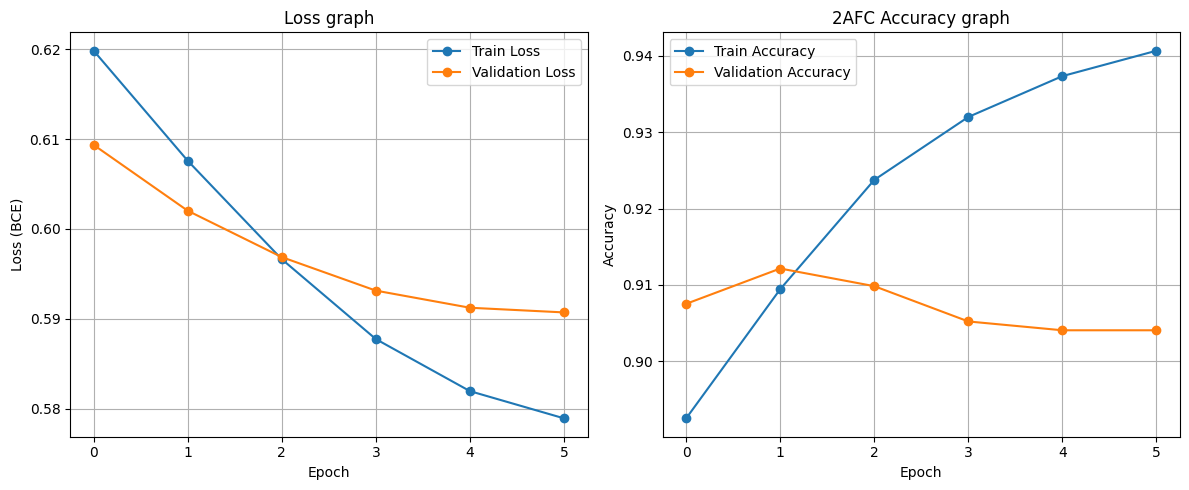

In [ ]:
plot_history(history)

## Training 2: MoH Attention

In [ ]:
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

1.920812544 GB allocated
2.199912448 GB reserved


In [ ]:
model_to_train_moh = PerceptualViTWrapper(backbone_moh)

trainable = sum(p.numel() for p in model_to_train_moh.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_to_train_moh.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable: 14,198,784 / 85,820,160 (16.5%)


In [ ]:
model_moh = model_to_train_moh.to(DEVICE)

# only pass trainable params to the optimizer — smaller optimizer state
optimizer = optim.AdamW(
    [p for p in model_moh.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
scaler = torch.amp.GradScaler('cuda')

In [ ]:
history_moh = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_aux_loss': []  # tracked separately to inspect router behavior
}

best_val_acc = 0.0

for epoch in range(EPOCHS):
    model_moh.train()
    running_loss, running_aux_loss, correct_train, total_train = 0.0, 0.0, 0, 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for ref, left, right, label, _ in train_loop:

        ref = ref.to(DEVICE, non_blocking=True)
        left = left.to(DEVICE, non_blocking=True)
        right = right.to(DEVICE, non_blocking=True)
        label = label.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            emb_ref, emb_left, emb_right = model_moh(ref, left, right)

            sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
            sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)

            logits = sim_left - sim_right
            main_loss = criterion(logits, label)

            # Collect MoH load-balancing aux loss from every routed block
            aux_loss_total = sum(
                model_moh.backbone.blocks[i].attn.aux_loss for i in moh_blocks_indices
            )
            loss = main_loss + AUX_LOSS_WEIGHT * aux_loss_total

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += main_loss.item() * ref.size(0)
        running_aux_loss += aux_loss_total.item() * ref.size(0)

        preds = (logits > 0).float()
        targets = (label > 0.5).float()
        correct_train += (preds == targets).sum().item()
        total_train += label.size(0)

        train_loop.set_postfix(loss=loss.item(), aux=aux_loss_total.item())

    epoch_train_loss = running_loss / total_train
    epoch_train_aux_loss = running_aux_loss / total_train
    epoch_train_acc = correct_train / total_train

    # Validation
    model_moh.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)

        for ref, left, right, label, _ in val_loop:
            ref = ref.to(DEVICE, non_blocking=True)
            left = left.to(DEVICE, non_blocking=True)
            right = right.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda'):
                emb_ref, emb_left, emb_right = model_moh(ref, left, right)

                sim_left = F.cosine_similarity(emb_ref, emb_left, dim=1)
                sim_right = F.cosine_similarity(emb_ref, emb_right, dim=1)

                logits = sim_left - sim_right
                # validation accuracy/loss reported on main task loss only,
                # aux loss is a training-time regularizer, not an eval metric
                loss = criterion(logits, label)

            val_loss += loss.item() * ref.size(0)

            preds = (logits > 0).float()
            targets = (label > 0.5).float()
            correct_val += (preds == targets).sum().item()
            total_val += label.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    history_moh['train_loss'].append(epoch_train_loss)
    history_moh['train_aux_loss'].append(epoch_train_aux_loss)
    history_moh['val_loss'].append(epoch_val_loss)
    history_moh['train_acc'].append(epoch_train_acc)
    history_moh['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} (aux: {epoch_train_aux_loss:.4f}), "
          f"Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # Saving weights for model with best accuracy on validation
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        print(f"\t --> Saving model with validation accuracy: {epoch_val_acc:.4f}")

        moh_performance["train_acc"] = epoch_train_acc
        moh_performance["val_acc"] = epoch_val_acc

        torch.save(model_moh.state_dict(), MOH_ATTENTION_PATH)

    scheduler.step()

print(f'[MoHAttention] 2AFC accuracy: {moh_performance["val_acc"]}')

Epoch [1/6] Train Loss: 0.6060 (aux: 0.4047), Train Acc: 0.9130 | Val Loss: 0.6037, Val Acc: 0.9179
	 --> Saving model with validation accuracy: 0.9179


Epoch [2/6] Train Loss: 0.6008 (aux: 0.4046), Train Acc: 0.9144 | Val Loss: 0.6013, Val Acc: 0.9145


Epoch [3/6] Train Loss: 0.5957 (aux: 0.4043), Train Acc: 0.9217 | Val Loss: 0.5990, Val Acc: 0.9179


Epoch [4/6] Train Loss: 0.5915 (aux: 0.4042), Train Acc: 0.9242 | Val Loss: 0.5971, Val Acc: 0.9121


Epoch [5/6] Train Loss: 0.5882 (aux: 0.4041), Train Acc: 0.9280 | Val Loss: 0.5960, Val Acc: 0.9110


Epoch [6/6] Train Loss: 0.5866 (aux: 0.4041), Train Acc: 0.9306 | Val Loss: 0.5957, Val Acc: 0.9110
[MoHAttention] 2AFC accuracy: 0.9179190751445087


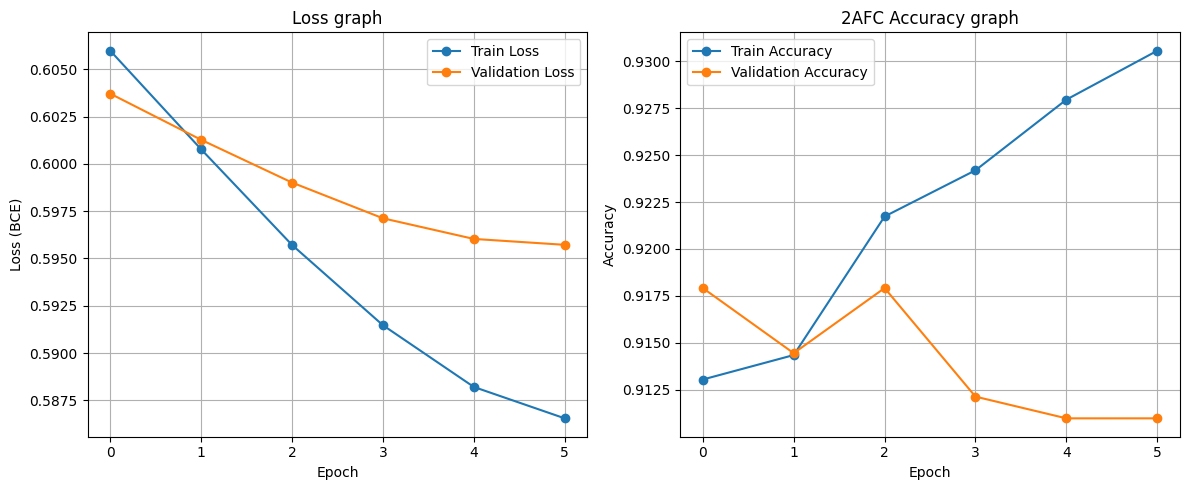

In [ ]:
plot_history(history_moh)

### Performances of the models


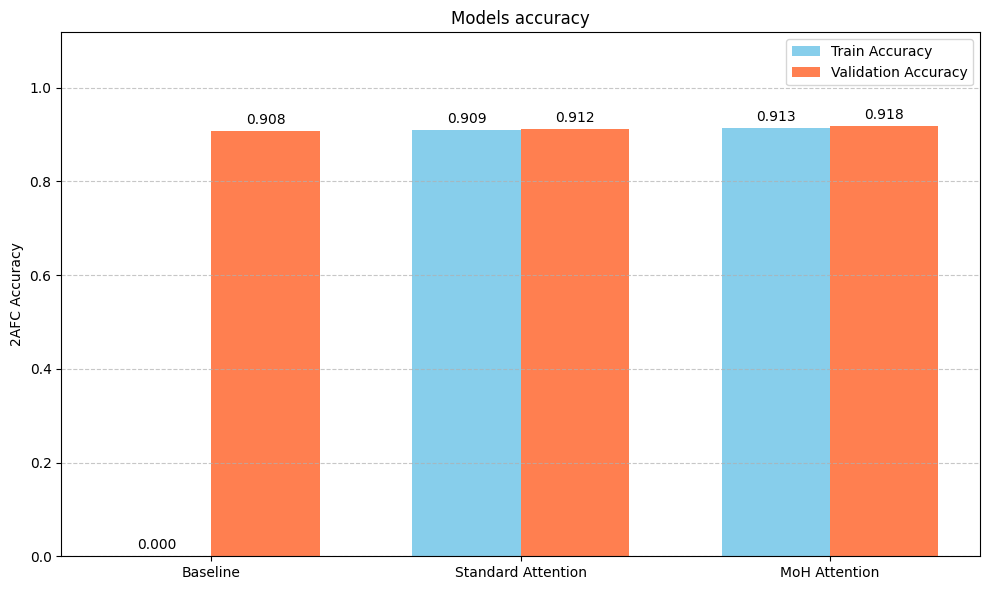

In [ ]:
models = ['Baseline', 'Standard Attention', 'MoH Attention']

train_accuracies = [0, standard_performance['train_acc'], moh_performance['train_acc']]
val_accuracies = [baseline_performance['val_acc'], standard_performance['val_acc'], moh_performance['val_acc']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy', color='coral')

ax.set_ylabel('2AFC Accuracy')
ax.set_title('Models accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

max_val = max(max(train_accuracies), max(val_accuracies))
ax.set_ylim(0, max_val + 0.2)

autolabel_rects(rects1)
autolabel_rects(rects2)


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluation

### Baseline model

In [ ]:
test_baseline = model_zs
baseline_stats = test_model_performance(test_baseline, test_loader, criterion, 'Baseline', DEVICE)

Warming-up GPU
Beginning test on the test set



Results for Baseline
Test Loss     : 0.6251
2AFC Accuracy : 0.8835 (88.35%)
Inference Time: 0.82 ms / triplet (± 0.39 ms)
Throughput    : 1222.7 triplet/sec


### Model 1: Standard attention

In [ ]:
state_dict_std = torch.load(STANDARD_ATTENTION_PATH, map_location=DEVICE, weights_only=True)
test_standard = model
test_standard.load_state_dict(state_dict_std)

standard_attention_stats = test_model_performance(test_standard, test_loader, criterion, 'Standard Attention', DEVICE)

Warming-up GPU
Beginning test on the test set



Results for Standard Attention
Test Loss     : 0.6109
2AFC Accuracy : 0.8893 (88.93%)
Inference Time: 0.79 ms / triplet (± 0.38 ms)
Throughput    : 1272.0 triplet/sec


### Model 2: MoH attention

In [ ]:
state_dict_moh = torch.load(MOH_ATTENTION_PATH, map_location=DEVICE, weights_only=True)
test_moh = model_moh
test_moh.load_state_dict(state_dict_moh)

moh_stats = test_model_performance(test_moh, test_loader, criterion, 'MoH', DEVICE)

Warming-up GPU
Beginning test on the test set



Results for MoH
Test Loss     : 0.6110
2AFC Accuracy : 0.8858 (88.58%)
Inference Time: 7.53 ms / triplet (± 0.49 ms)
Throughput    : 132.8 triplet/sec


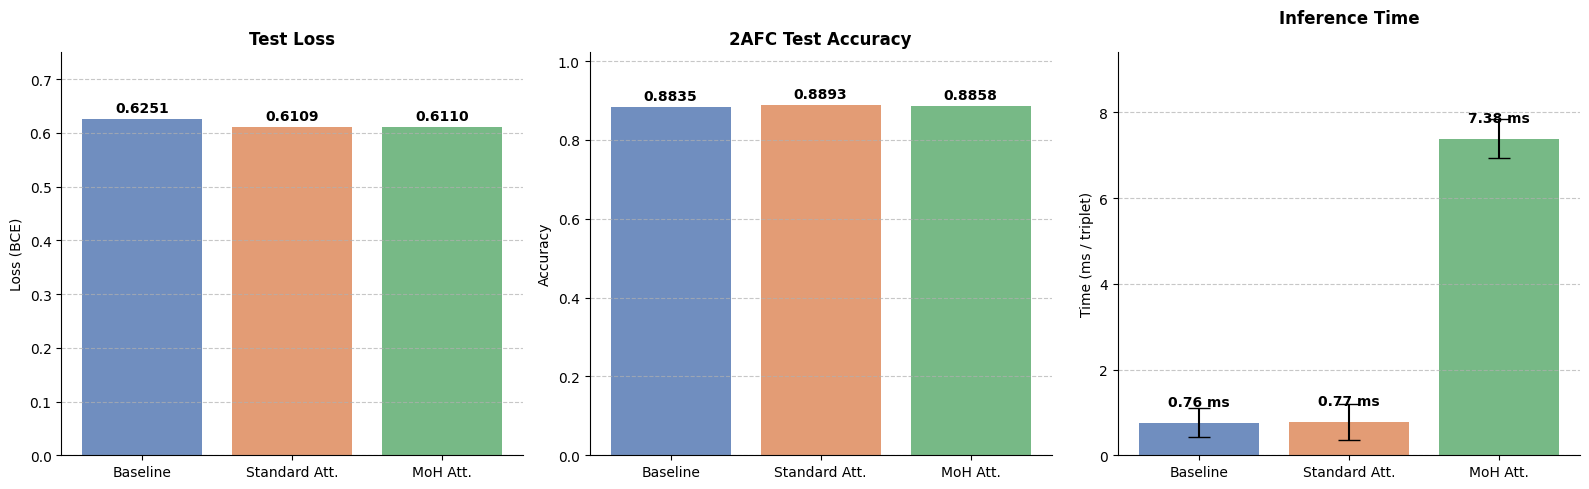

In [ ]:
plot_test_results(baseline_stats, standard_attention_stats, moh_stats)